# Churn Prediction: Modelling

* Load the cleaned dataset produced in `Data-analysis-and-preparation.ipynb`
* Check class balance
* Compare multiple ML techniques via cross-validation
* Handle class imbalance if the baseline results suggest it's needed
* Tune hyperparameters on the best-performing model/strategy combination
* Evaluate the final model on a held-out test set

In [36]:
# imports
# requires imbalanced-learn: pip install imbalanced-learn

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, make_scorer, precision_score, recall_score, f1_score)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import joblib
import os

RANDOM_STATE = 42


# 1. Load Data

In [37]:
df = pd.read_csv('./data/final_df.csv')
print(df.shape)
print(df.isna().sum().sum(), "missing values")
df.head()


(1000, 28)
0 missing values


,ChurnStatus,Age,IncomeLevel,NumTransactions,AvgTransactionAmount,TotalTransactionAmount,NumUniqueProductCategories,SpendingVolatility,CustomerTenureDays,TransactionFrequency,...,HasServiceInteraction,DaysSinceLastTransaction_log,RecencyTenureRatio_log,PctComplaint_log,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,ServiceUsage_Online Banking,ServiceUsage_Website
0,0,0.862745,2,0.000,0.834787,-1.152196,0.00,0.456465,-0.092667,0.011940,...,1,1.591983,2.017698,-0.620476,True,False,True,False,False,False
1,1,0.921569,2,0.750,0.433630,0.379758,0.75,0.356847,0.904168,0.263067,...,1,-0.068989,-0.607514,-0.620476,True,True,False,False,False,True
2,0,0.000000,2,0.625,0.562470,0.590481,0.75,0.397518,0.476953,0.246008,...,1,0.531342,-0.066836,-0.620476,True,False,True,False,False,True
3,0,0.058824,2,0.500,0.356448,-0.473822,0.75,0.391811,-0.817637,0.305561,...,1,-1.853819,-1.023352,-0.620476,True,False,False,True,False,True
4,0,0.058824,3,0.875,0.493414,0.994845,0.50,0.386411,0.347494,0.354988,...,0,-1.232894,-0.967213,-0.620476,True,False,False,False,False,True


# 2. Check Class Balance

ChurnStatus
0    796
1    204
Name: count, dtype: int64
ChurnStatus
0    79.6%
1    20.4%
Name: proportion, dtype: str


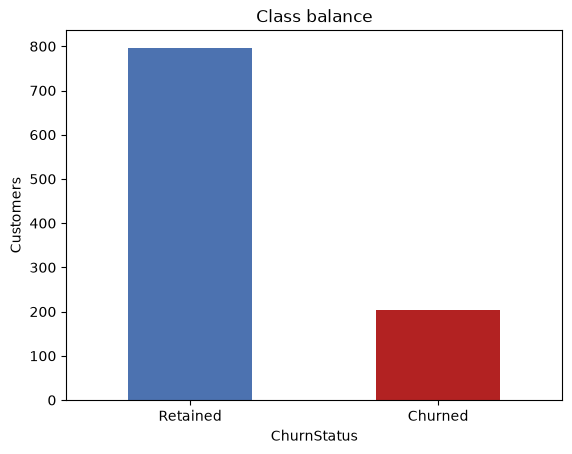


Minority class share: 20.4%
Meaningfully imbalanced - worth testing imbalance-handling strategies below.


In [38]:
class_counts = df['ChurnStatus'].value_counts().sort_index()
class_pct = df['ChurnStatus'].value_counts(normalize=True).sort_index()
print(class_counts)
print((class_pct * 100).round(1).astype(str) + '%')

class_counts.plot(kind='bar', color=['#4C72B0', '#B22222'])
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Customers')
plt.title('Class balance')
plt.show()

minority_share = class_pct.min()
print(f"\nMinority class share: {minority_share:.1%}")
print("Meaningfully imbalanced - worth testing imbalance-handling strategies below."
      if minority_share < 0.35 else
      "Reasonably balanced - imbalance handling probably won't move the needle much, but we'll check anyway.")


# 3. Train/Test Split

In [39]:
X = df.drop(columns='ChurnStatus')
y = df['ChurnStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.1%}")


Train: (800, 27), churn rate 20.4%
Test:  (200, 27), churn rate 20.5%


In [40]:
# ROC-AUC rewards good ranking overall but can hide poor recall on the minority class; for a
# churn use case, F1 (precision/recall balance) is more representative for business value
PRIMARY_METRIC = 'F1'


# 4. Compare Modelling Techniques x Class Imbalance Strategies

Run the full cross of every model against every strategy. Different algorithms respond differently to resampling (distance-based models like KNN/SVM are typically more sensitive to imbalance than tree ensembles), so the best model overall and the best model for each startegy aren't guaranteed to be the same - a sequential/greedy search can miss the actual best combination.

In [41]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'K-Nearest Neighbours': KNeighborsClassifier(),
    'Support Vector Machine': CalibratedClassifierCV(SVC(), ensemble=False),
    'Neural Network': MLPClassifier(max_iter=1000, random_state=RANDOM_STATE),
}

STRATEGIES = {
    'No handling': None,
    'Random Oversampling': RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'Random Undersampling': RandomUnderSampler(random_state=RANDOM_STATE),
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
}


def build_pipeline(model, sampler=None):
    steps = [('scaler', StandardScaler())]
    if sampler is not None:
        steps.append(('sampler', sampler))
    steps.append(('model', model))
    return ImbPipeline(steps)


def cv_scores(pipe, X, y, cv=CV, scoring=SCORING):
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {m.capitalize(): scores[f'test_{m}'].mean() for m in scoring}


full_grid_rows = []
for model_name, model in models.items():
    for strategy_name, sampler in STRATEGIES.items():
        full_grid_rows.append({'Model': model_name, 'Strategy': strategy_name,
                                **cv_scores(build_pipeline(model, sampler), X_train, y_train)})
    # class_weight is a model hyperparameter rather than a sampler, so it's tested separately
    if 'class_weight' in model.get_params():
        weighted_model = clone(model).set_params(class_weight='balanced')
        full_grid_rows.append({'Model': model_name, 'Strategy': 'Class Weight (balanced)',
                                **cv_scores(build_pipeline(weighted_model, None), X_train, y_train)})

full_grid_results = pd.DataFrame(full_grid_rows).sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)
full_grid_results.head(10)


,Model,Strategy,Accuracy,Precision,Recall,F1,Roc_auc
0,Gradient Boosting,Random Undersampling,0.53875,0.239412,0.583144,0.338959,0.558633
1,Logistic Regression,Random Undersampling,0.53000,0.232934,0.564773,0.329514,0.537681
2,Logistic Regression,SMOTE,0.57750,0.234124,0.479545,0.314030,0.529704
3,Logistic Regression,Class Weight (balanced),0.56875,0.231860,0.484659,0.312831,0.536009
4,K-Nearest Neighbours,Random Undersampling,0.55375,0.227285,0.497348,0.311768,0.513843
5,Random Forest,Random Undersampling,0.52125,0.220293,0.533902,0.311475,0.532300
6,Decision Tree,Random Undersampling,0.50000,0.215791,0.545833,0.308784,0.517048
7,Neural Network,Random Undersampling,0.51500,0.215761,0.527652,0.305750,0.518738
8,Logistic Regression,Random Oversampling,0.54750,0.211697,0.453977,0.288200,0.517046
9,Support Vector Machine,Random Undersampling,0.48125,0.198501,0.502841,0.283979,0.522305


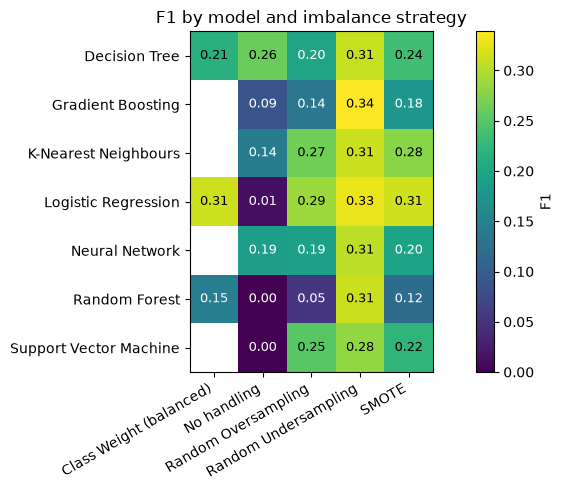

In [42]:
# heatmap of every model x strategy combination, coloured by F1
pivot = full_grid_results.pivot_table(index='Model', columns='Strategy', values=PRIMARY_METRIC)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot, cmap='viridis')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                     color='white' if val < pivot.values[~pd.isna(pivot.values)].mean() else 'black', fontsize=9)
plt.colorbar(im, label=PRIMARY_METRIC)
plt.title(f'{PRIMARY_METRIC} by model and imbalance strategy')
plt.tight_layout()
plt.show()


# 5. Select the Top 3 Candidates

In [43]:
top3_candidates = full_grid_results.sort_values(PRIMARY_METRIC, ascending=False).head(3).reset_index(drop=True)

print(f"Top 3 candidates by {PRIMARY_METRIC}:")
top3_candidates


Top 3 candidates by F1:


,Model,Strategy,Accuracy,Precision,Recall,F1,Roc_auc
0,Gradient Boosting,Random Undersampling,0.53875,0.239412,0.583144,0.338959,0.558633
1,Logistic Regression,Random Undersampling,0.53000,0.232934,0.564773,0.329514,0.537681
2,Logistic Regression,SMOTE,0.57750,0.234124,0.479545,0.314030,0.529704


# 6. Hyperparameter Tuning

Run a randomised search on each of the top 3 candidates separately, optimising for F1, then compare the tuned results before picking an overall winner in the next section.

In [44]:
PARAM_GRIDS = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__l1_ratio': [0, 1],
        'model__solver': ['liblinear'],
    },
    'Decision Tree': {
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [None, 3, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
    },
    'Random Forest': {
        'model__n_estimators': [100, 200, 400, 600],
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 400],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__max_depth': [2, 3, 4, 5],
        'model__subsample': [0.7, 0.85, 1.0],
    },
    'K-Nearest Neighbours': {
        'model__n_neighbors': [3, 5, 7, 9, 11, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2],
    },
    'Support Vector Machine': {
        'model__C': [0.1, 1, 10, 100],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto'],
    },
    'Neural Network': {
        'model__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
        'model__activation': ['relu', 'tanh'],
        'model__alpha': [0.0001, 0.001, 0.01, 0.1],
        'model__learning_rate_init': [0.001, 0.01],
    },
}


tuned_candidates = []
for _, row in top3_candidates.iterrows():
    model_name, strategy_name = row['Model'], row['Strategy']
    model = models[model_name]
    if strategy_name == 'Class Weight (balanced)':
        final_model, final_sampler = clone(model).set_params(class_weight='balanced'), None
    else:
        final_model, final_sampler = model, STRATEGIES.get(strategy_name)

    grid_search = GridSearchCV(
        build_pipeline(final_model, final_sampler),
        param_grid=PARAM_GRIDS[model_name],
        cv=CV,
        scoring=SCORING[PRIMARY_METRIC.lower()],  # reuses the same scorer defined in section 4
        n_jobs=-1,
        verbose=0,
    )
    grid_search.fit(X_train, y_train)
    print(f"{model_name} + {strategy_name}: best CV {PRIMARY_METRIC} = {grid_search.best_score_:.3f}")
    print(f"  best params: {grid_search.best_params_}\n")

    tuned_candidates.append({'Model': model_name, 'Strategy': strategy_name,
                              'CV_score': grid_search.best_score_, 'estimator': grid_search.best_estimator_})


Gradient Boosting + Random Undersampling: best CV F1 = 0.352
  best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}

Logistic Regression + Random Undersampling: best CV F1 = 0.330
  best params: {'model__C': 1, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}

Logistic Regression + SMOTE: best CV F1 = 0.325
  best params: {'model__C': 0.1, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}



# 7. Final Evaluation on Test Set

Evaluate all 3 tuned candidates on the held-out test set (the real generalisation check, rather than the CV score used to tune them), then look more closely at whichever one wins there.

In [45]:
test_rows = []
for cand in tuned_candidates:
    y_pred = cand['estimator'].predict(X_test)
    y_proba = cand['estimator'].predict_proba(X_test)[:, 1]
    test_rows.append({
        'Model': cand['Model'], 'Strategy': cand['Strategy'], 'CV_score': cand['CV_score'],
        'Test_Precision': precision_score(y_test, y_pred, zero_division=0),
        'Test_Recall': recall_score(y_test, y_pred, zero_division=0),
        'Test_F1': f1_score(y_test, y_pred, zero_division=0),
        'Test_Roc_auc': roc_auc_score(y_test, y_proba),
    })

test_comparison = pd.DataFrame(test_rows).sort_values(f'Test_{PRIMARY_METRIC}', ascending=False).reset_index(drop=True)
test_comparison


,Model,Strategy,CV_score,Test_Precision,Test_Recall,Test_F1,Test_Roc_auc
0,Logistic Regression,Random Undersampling,0.329514,0.213592,0.536585,0.305556,0.526615
1,Logistic Regression,SMOTE,0.324569,0.173469,0.414634,0.244604,0.485351
2,Gradient Boosting,Random Undersampling,0.352204,0.166667,0.390244,0.233577,0.468937


In [46]:
winner_name = test_comparison.iloc[0]
best_pipeline = next(c['estimator'] for c in tuned_candidates
                      if c['Model'] == winner_name['Model'] and c['Strategy'] == winner_name['Strategy'])
print(f"Overall winner on the test set: {winner_name['Model']} + {winner_name['Strategy']}")

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))


Overall winner on the test set: Logistic Regression + Random Undersampling
              precision    recall  f1-score   support

    Retained       0.80      0.49      0.61       159
     Churned       0.21      0.54      0.31        41

    accuracy                           0.50       200
   macro avg       0.51      0.51      0.46       200
weighted avg       0.68      0.50      0.55       200



# 8. Feature Importance

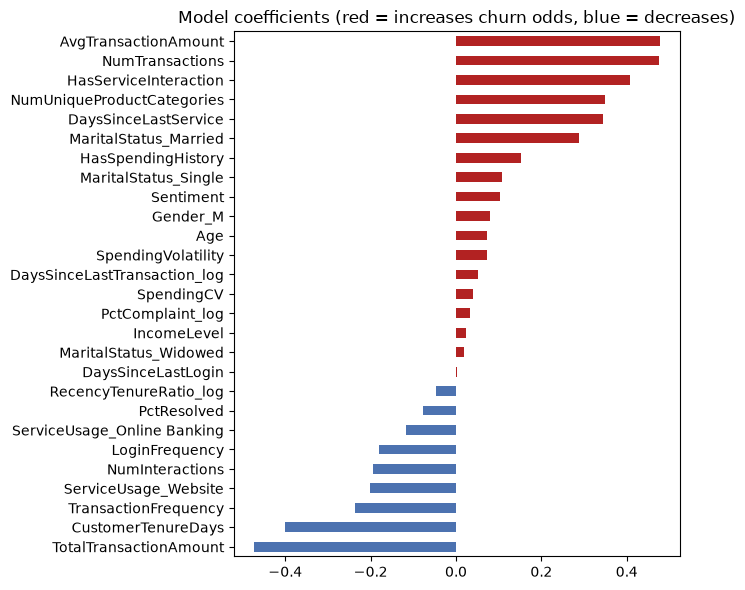

In [47]:
model_step = best_pipeline.named_steps['model']
feature_names = X_train.columns

if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=feature_names).sort_values()
    importances.tail(15).plot(kind='barh', figsize=(7, 6), color='#4C72B0')
    plt.title('Top 15 feature importances')
    plt.tight_layout()
    plt.show()
elif hasattr(model_step, 'coef_'):
    coefs = pd.Series(model_step.coef_[0], index=feature_names).sort_values()
    colours = ['#B22222' if c > 0 else '#4C72B0' for c in coefs]
    coefs.plot(kind='barh', figsize=(7, 6), color=colours)
    plt.title('Model coefficients (red = increases churn odds, blue = decreases)')
    plt.tight_layout()
    plt.show()
else:
    print("This model type doesn't expose feature importances or coefficients directly.")


Churners correctly identified (TP): 22
Churners missed (FN):               19
Retained wrongly flagged as churners (FP): 81
Retained correctly identified (TN): 78

Total actual churners: 41
Share of churners caught (recall): 53.7%
Share of flagged customers who really churn (precision): 21.4%


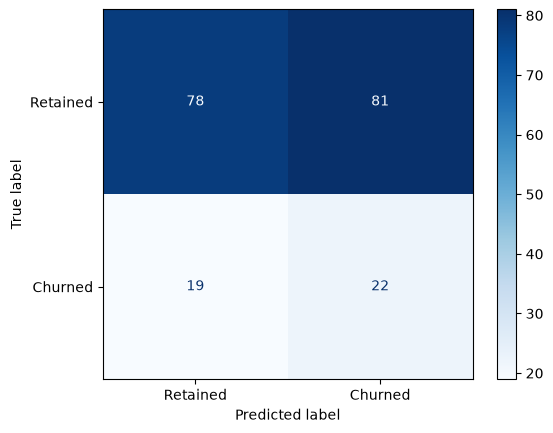

In [48]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"Churners correctly identified (TP): {tp}")
print(f"Churners missed (FN):               {fn}")
print(f"Retained wrongly flagged as churners (FP): {fp}")
print(f"Retained correctly identified (TN): {tn}")
print(f"\nTotal actual churners: {tp + fn}")
print(f"Share of churners caught (recall): {tp / (tp + fn):.1%}")
print(f"Share of flagged customers who really churn (precision): {tp / (tp + fp):.1%}")


ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Retained', 'Churned'], cmap='Blues'
)

# 9. Save the Final Model

In [49]:
os.makedirs('./models', exist_ok=True)
joblib.dump(best_pipeline, './models/churn_model.pkl')
print("Saved to ./models/churn_model.pkl")


Saved to ./models/churn_model.pkl
